In [159]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#Shows all the columns
pd.set_option('display.max_columns', None)

In [160]:
def fetch_csv(file_path,filename):
    return os.path.join(file_path,filename)
    
df = pd.read_csv(fetch_csv("datasets/house-prices-advanced-regression-techniques","train.csv"))
df.shape

(1460, 81)

In [161]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<Axes: xlabel='SalePrice', ylabel='Count'>

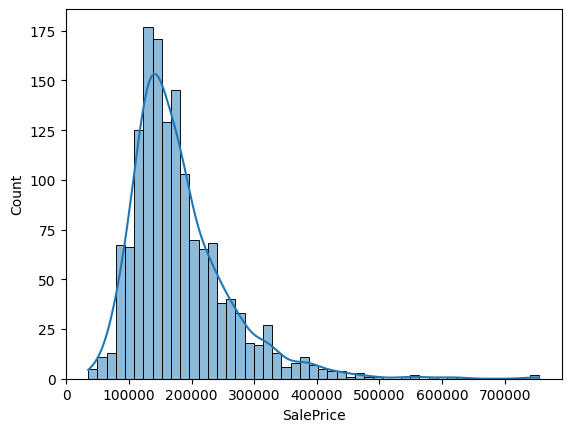

In [162]:
sns.histplot(df['SalePrice'],kde=True)

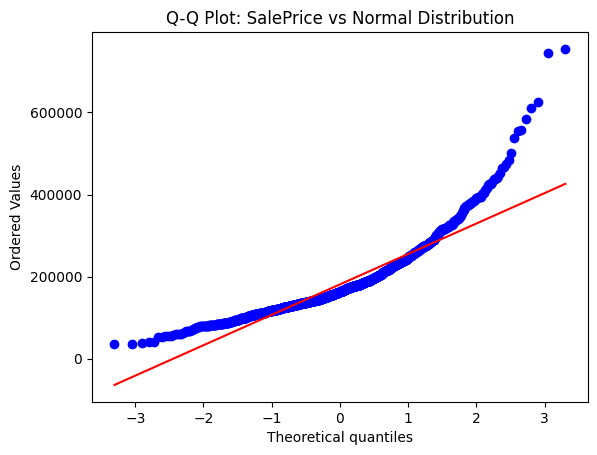

In [163]:
import scipy.stats as stats

stats.probplot(df['SalePrice'], dist="norm", plot=plt)
plt.title('Q-Q Plot: SalePrice vs Normal Distribution')
plt.show()

In [164]:
nullcount=df.isnull().mean() * 100
nullcount[nullcount>0]

LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64

In [165]:
df[['PoolQC','MiscFeature','Alley','MiscVal']]

,PoolQC,MiscFeature,Alley,MiscVal
0,NaN,NaN,NaN,0
1,NaN,NaN,NaN,0
2,NaN,NaN,NaN,0
3,NaN,NaN,NaN,0
4,NaN,NaN,NaN,0
...,...,...,...,...
1455,NaN,NaN,NaN,0
1456,NaN,NaN,NaN,0
1457,NaN,Shed,NaN,2500
1458,NaN,NaN,NaN,0


In [166]:
df = df.drop(columns=['PoolQC'])

In [167]:
print(df['MiscVal'].count())

1460


In [168]:
df = df.drop(columns=['MiscFeature'])

In [169]:
df['Alley'].value_counts(dropna=False)

Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

In [170]:
df['Alley']= df['Alley'].fillna('None')
df['Alley'].value_counts(dropna=False)

Alley
None    1369
Grvl      50
Pave      41
Name: count, dtype: int64

In [171]:
nullcount_revised=df.isnull().mean() * 100
nullcount_revised[nullcount>0]

LotFrontage     17.739726
Alley            0.000000
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
Fence           80.753425
dtype: float64

In [172]:
numerical_features_list = df.select_dtypes(include=np.number).columns.tolist()
print("Number of numerical-features: ", len(numerical_features_list))
categorical_features_list = df.select_dtypes(exclude=np.number).columns.tolist()
print("Number of categorical-features: ", len(categorical_features_list))

Number of numerical-features:  38
Number of categorical-features:  41


In [173]:
df[numerical_features_list].isnull().mean().sort_values(ascending=False).head(3)

LotFrontage    0.177397
GarageYrBlt    0.055479
MasVnrArea     0.005479
dtype: float64

In [174]:
# Lets Study the relationship between the numerical features first

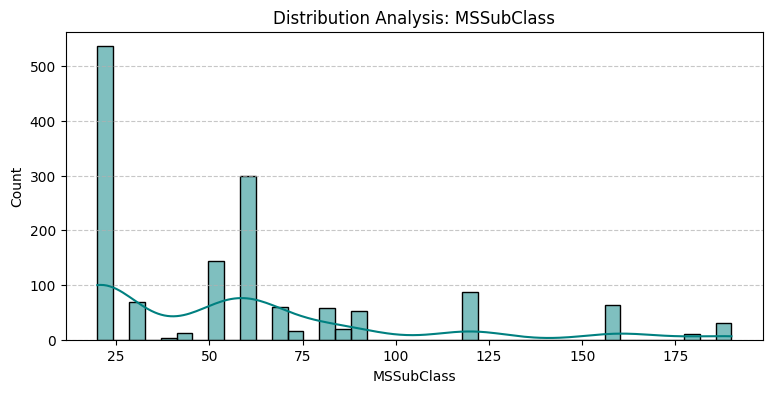

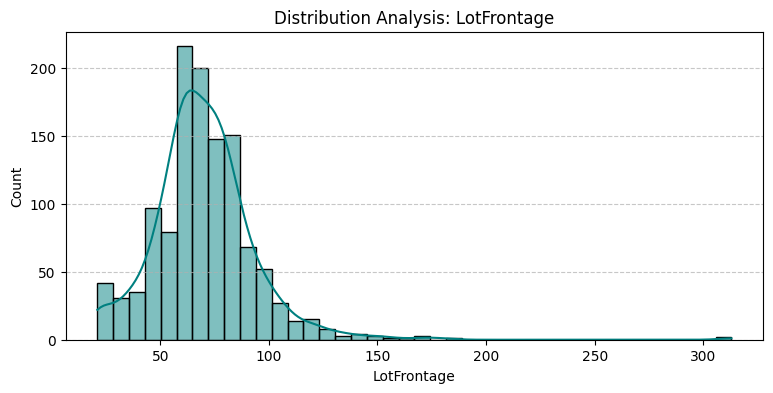

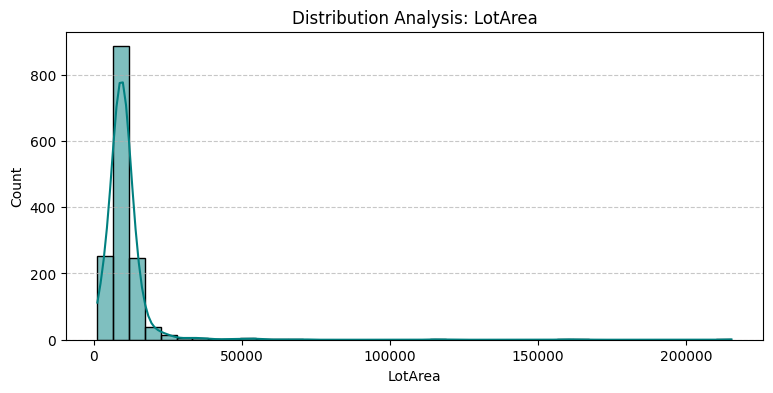

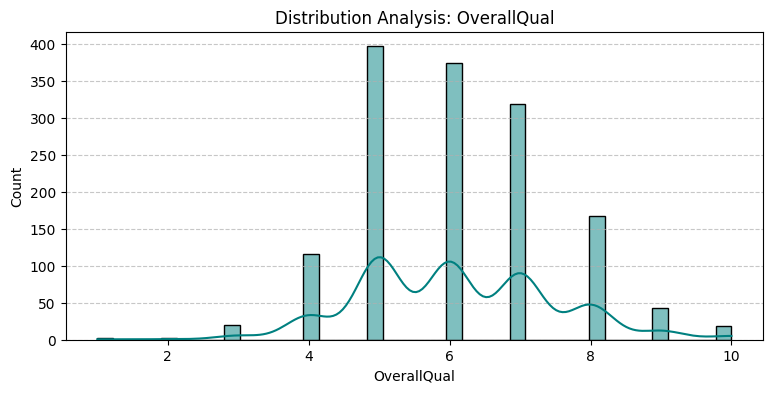

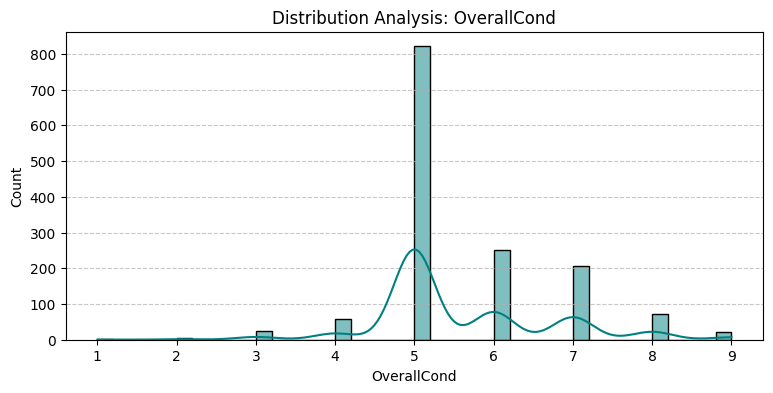

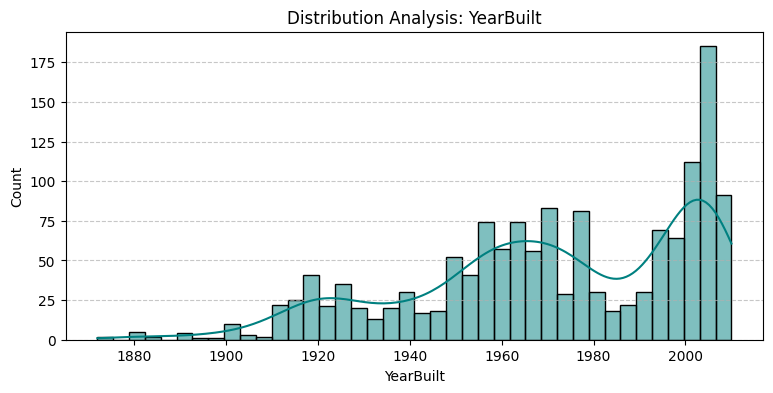

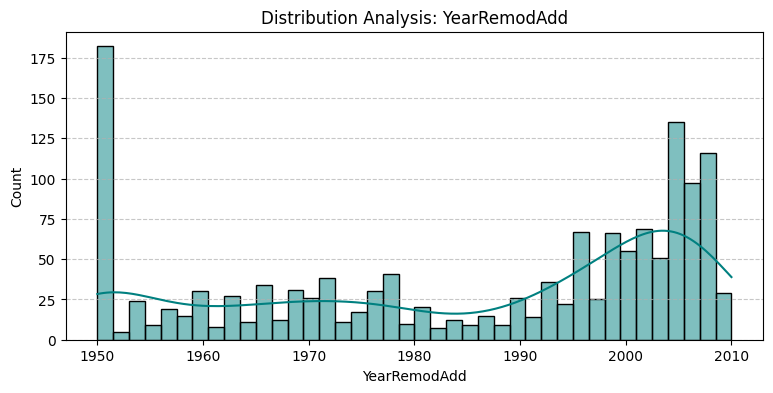

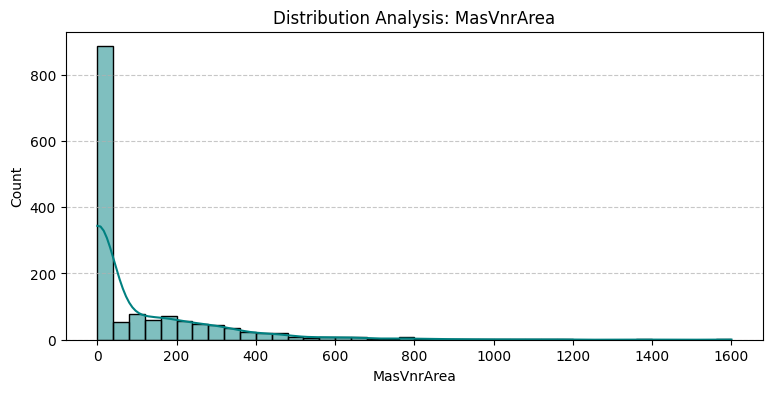

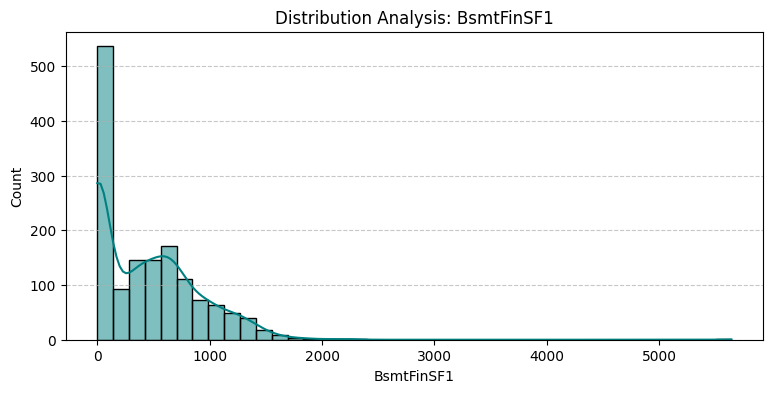

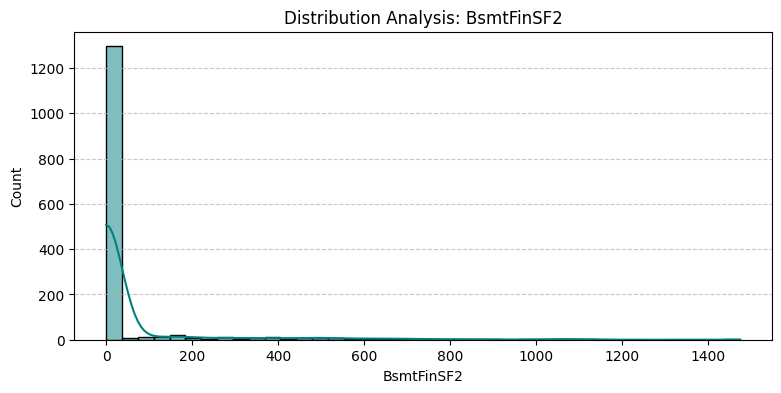

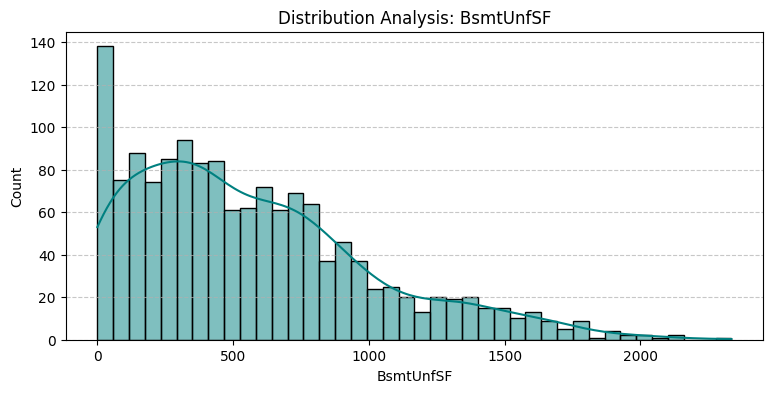

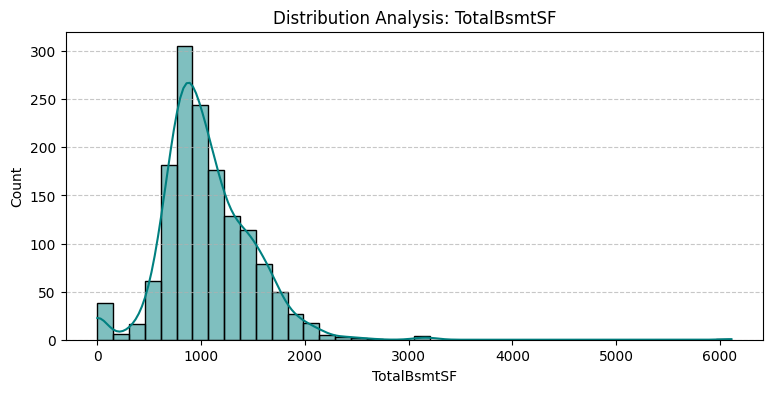

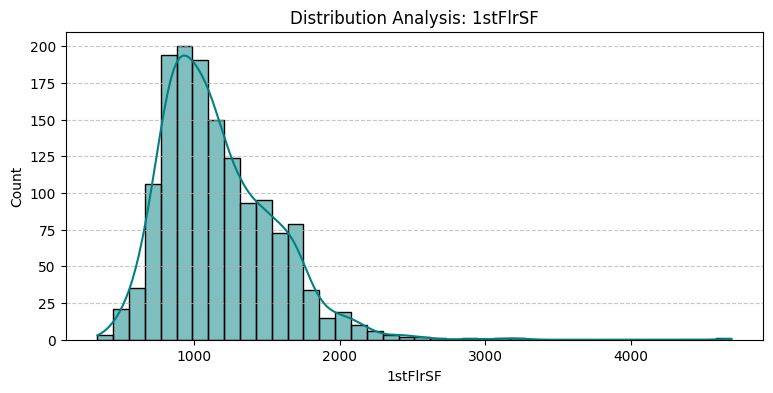

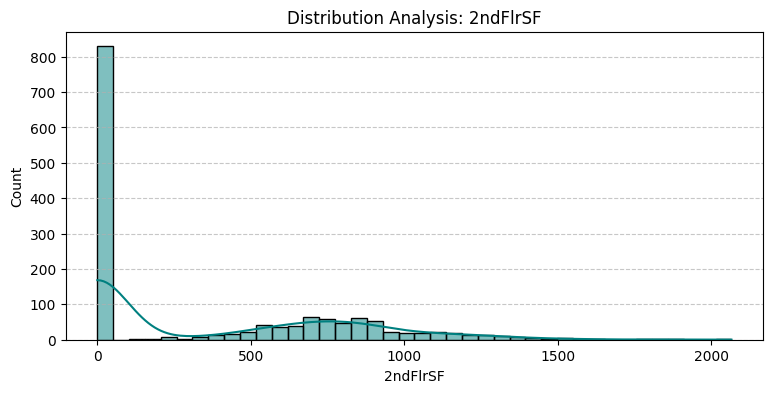

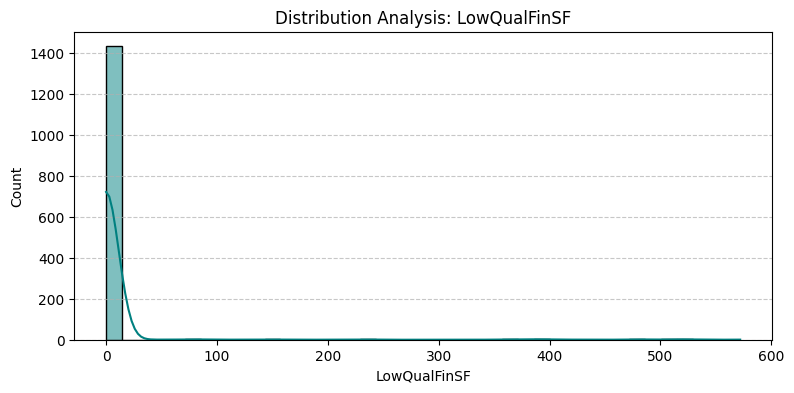

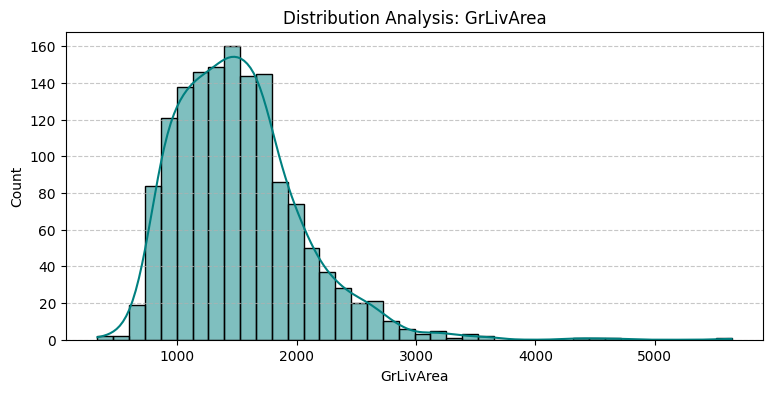

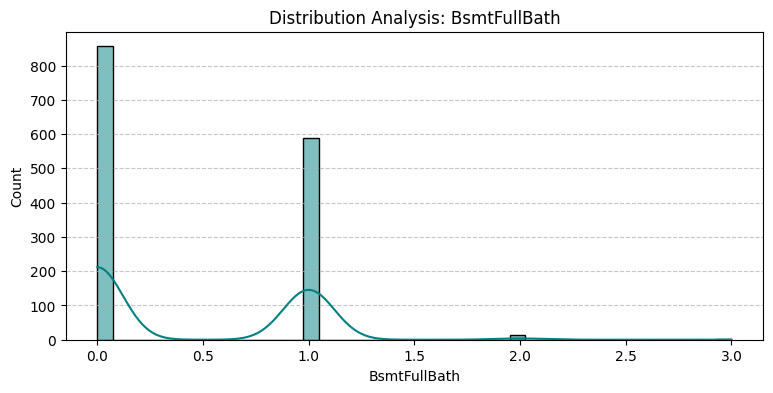

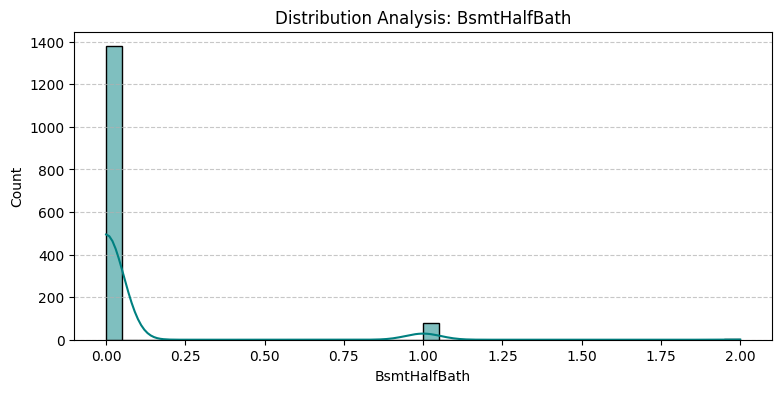

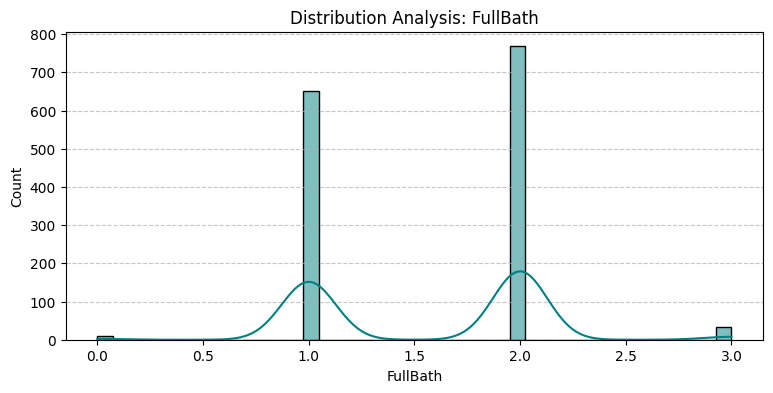

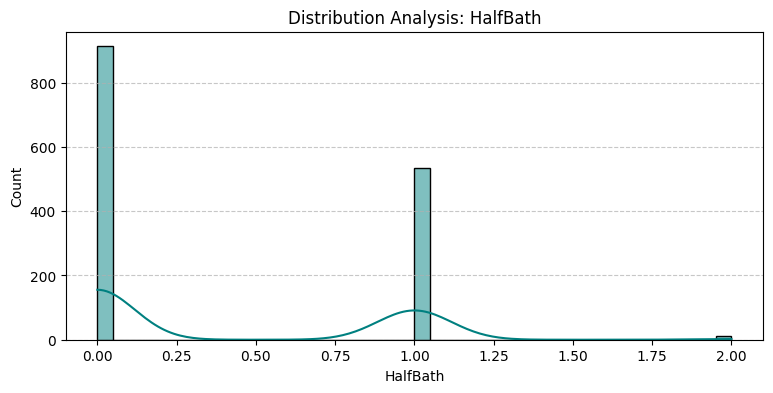

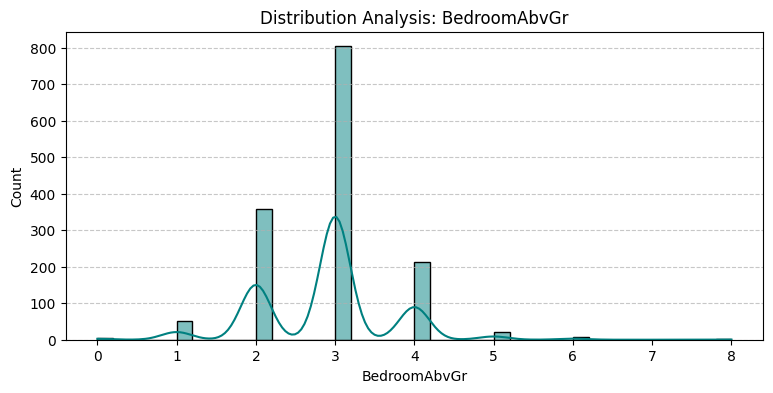

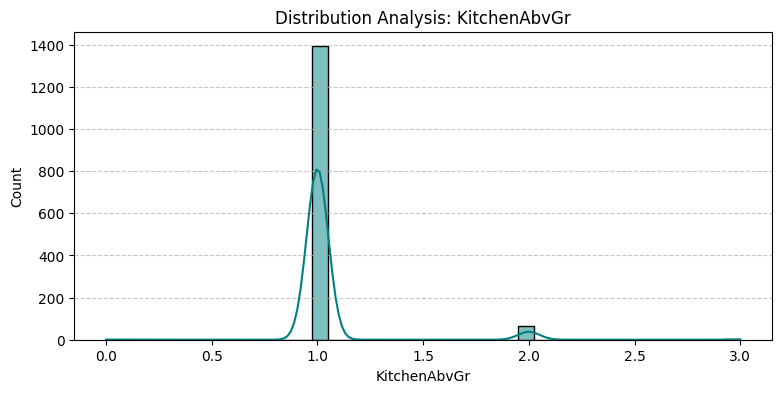

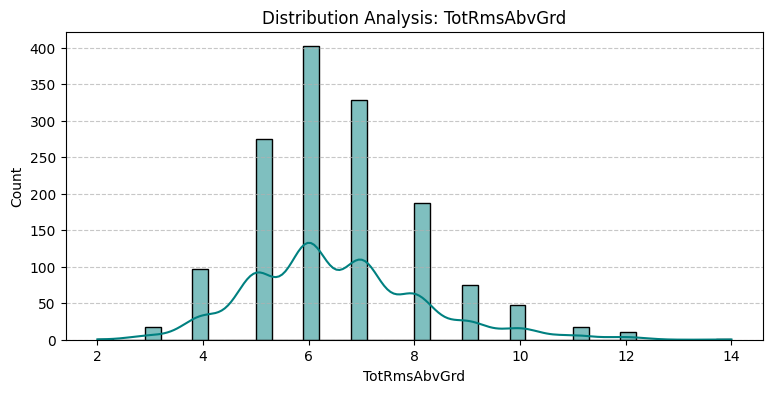

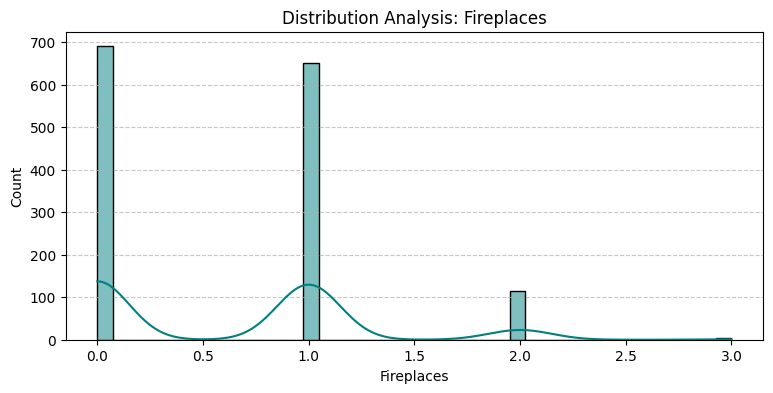

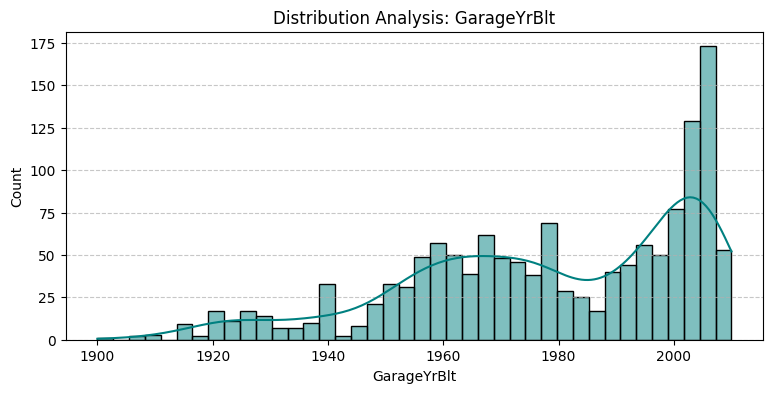

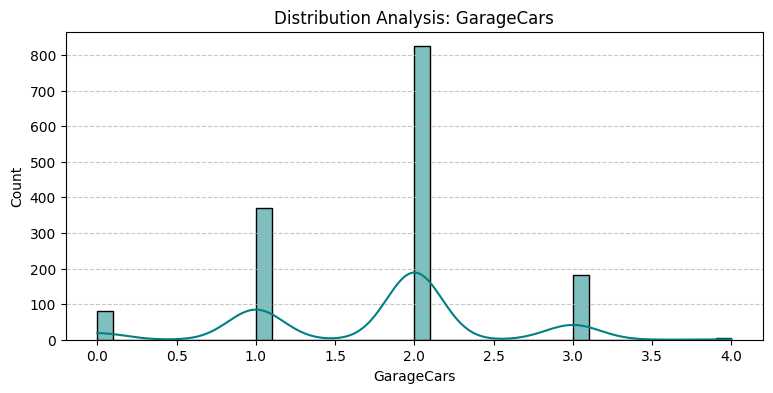

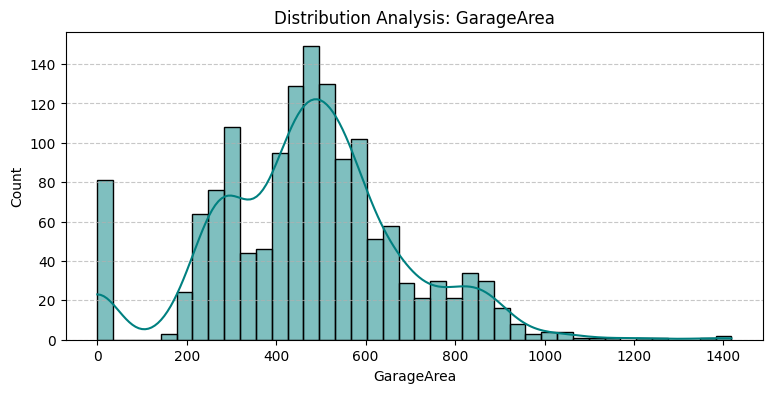

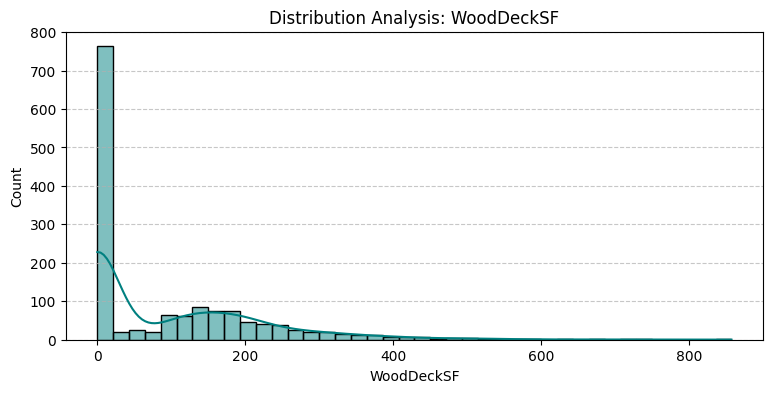

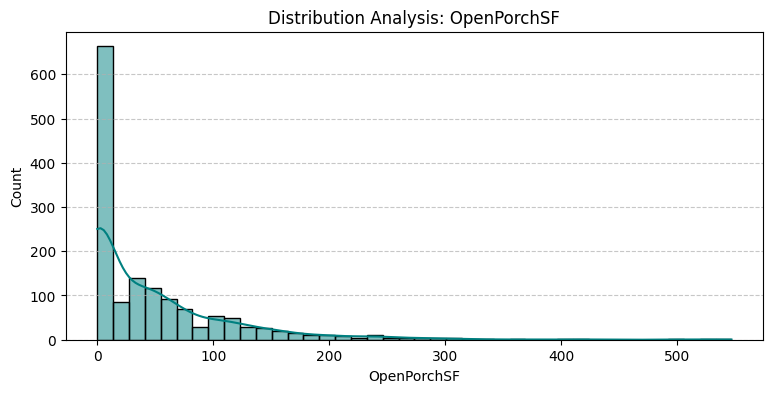

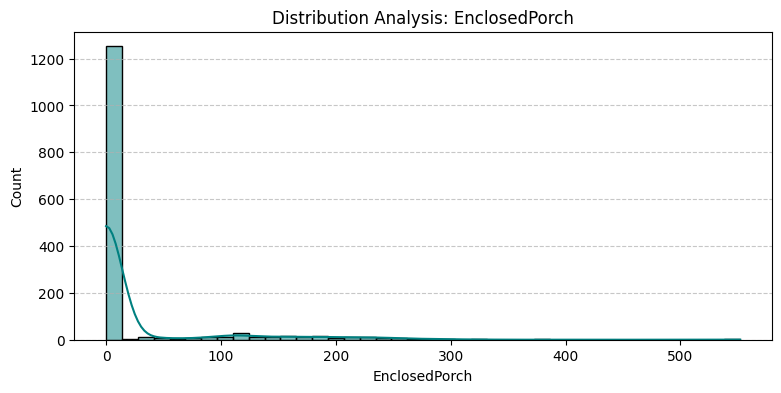

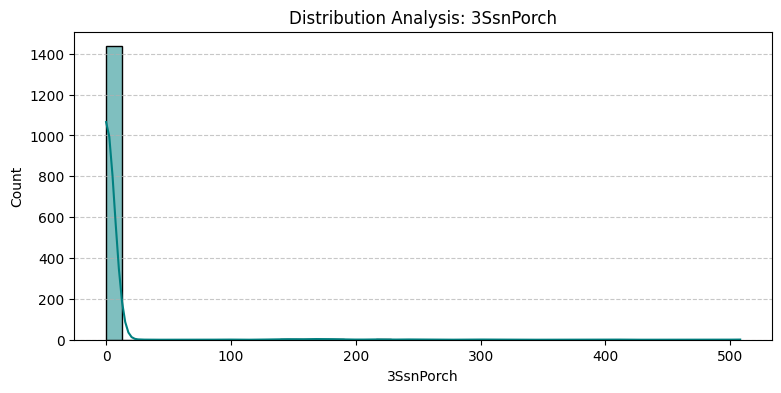

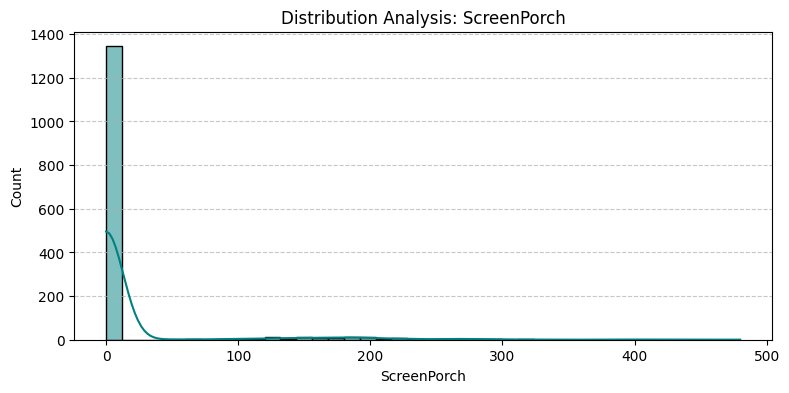

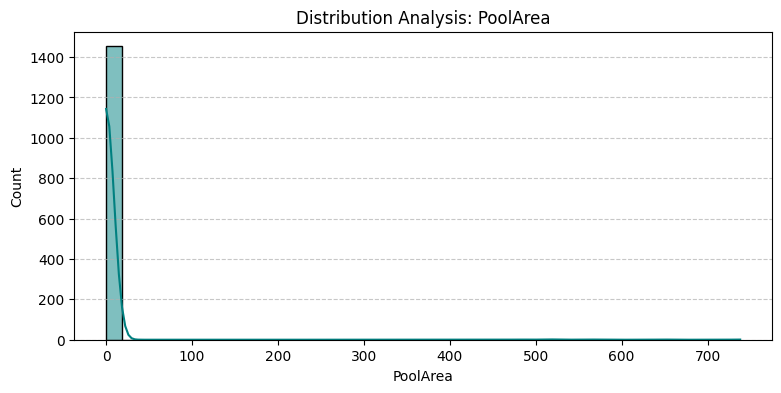

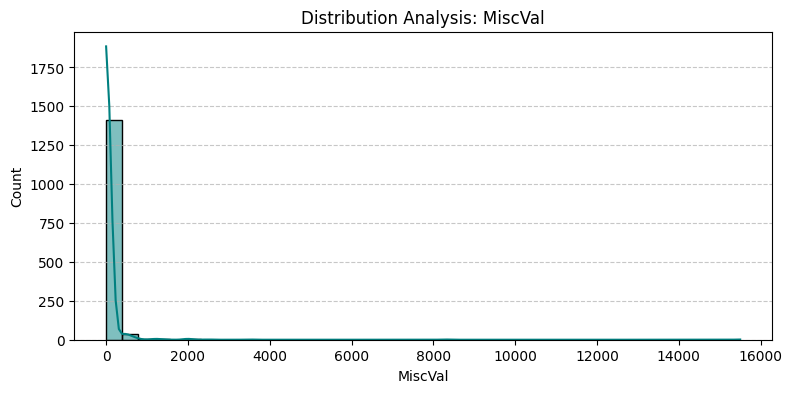

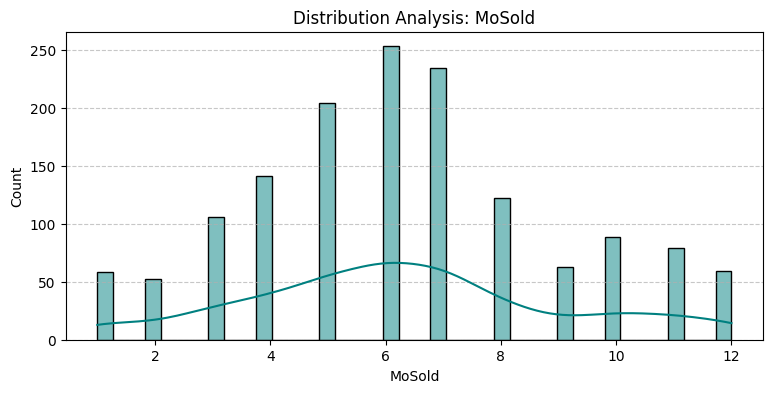

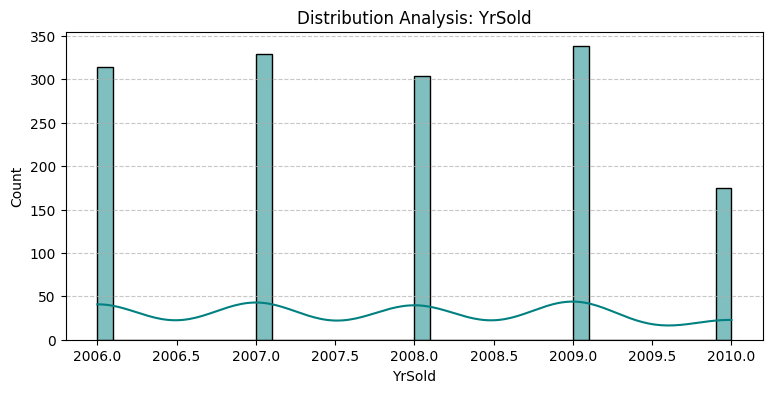

In [175]:
# Select a small subset or run through them with plenty of spacing
for feature in numerical_features_list[:]:  # Change index to see different batches
    if feature in ['Id', 'SalePrice', 'Log_SalePrice']:
        continue
        
    plt.figure(figsize=(9, 4))
    sns.histplot(data=df, x=feature, kde=True, color='teal', bins=40)
    plt.title(f'Distribution Analysis: {feature}', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    print("\n" + "="*50 + "\n") #Visual Separator

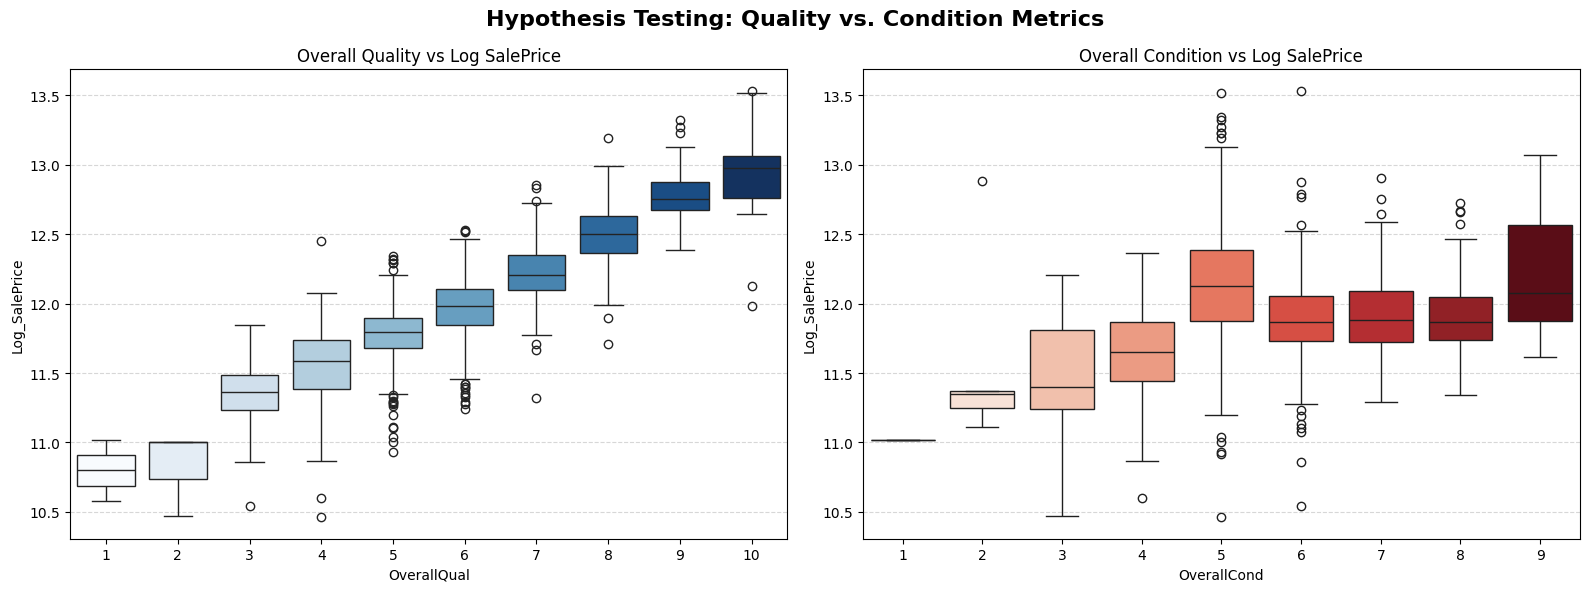

In [176]:
if 'Log_SalePrice' not in df.columns:
    df['Log_SalePrice'] = np.log1p(df['SalePrice'])

# Setting up the plotting grid
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hypothesis Testing: Quality vs. Condition Metrics', fontsize=16, weight='bold', y=0.98)


sns.boxplot(data=df, x='OverallQual', y='Log_SalePrice', ax=axes[0], hue='OverallQual', palette='Blues', legend=False)
axes[0].set_title('Overall Quality vs Log SalePrice', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)


sns.boxplot(data=df, x='OverallCond', y='Log_SalePrice', ax=axes[1], hue='OverallCond', palette='Reds', legend=False)
axes[1].set_title('Overall Condition vs Log SalePrice', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

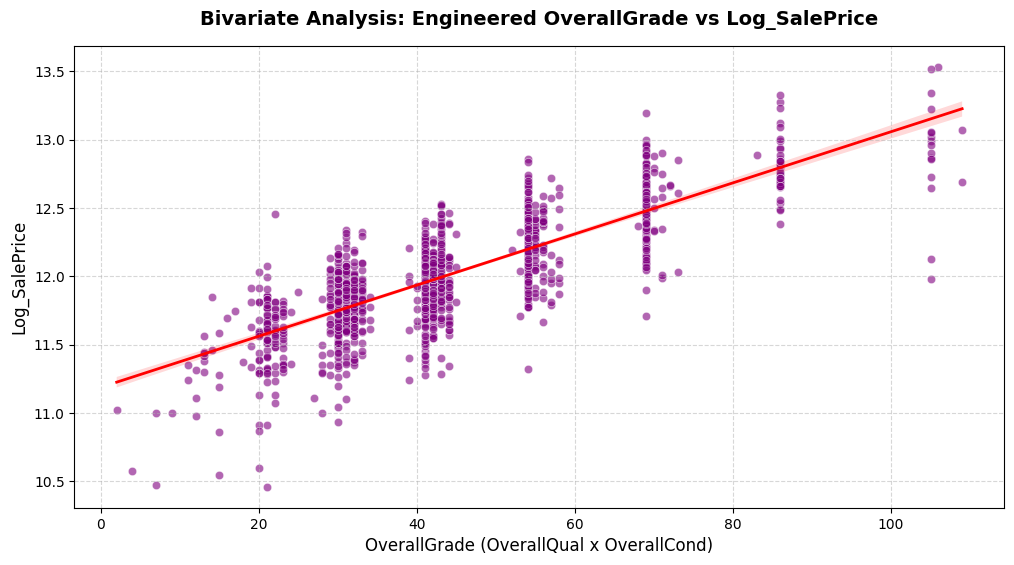

Correlation of OverallQual with Log_SalePrice: 0.8172
Correlation of Engineered OverallGrade with Log_SalePrice: 0.8147


In [177]:
df['OverallGrade'] = (df['OverallQual'] ** 2) + df['OverallCond']

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='OverallGrade', y='Log_SalePrice', alpha=0.6, color='purple')
sns.regplot(data=df, x='OverallGrade', y='Log_SalePrice', scatter=False, color='red', line_kws={"linewidth": 2})

plt.title('Bivariate Analysis: Engineered OverallGrade vs Log_SalePrice', fontsize=14, weight='bold', pad=15)
plt.xlabel('OverallGrade (OverallQual x OverallCond)', fontsize=12)
plt.ylabel('Log_SalePrice', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Correlation of OverallQual with Log_SalePrice: {df['OverallQual'].corr(df['Log_SalePrice']):.4f}")
print(f"Correlation of Engineered OverallGrade with Log_SalePrice: {df['OverallGrade'].corr(df['Log_SalePrice']):.4f}")

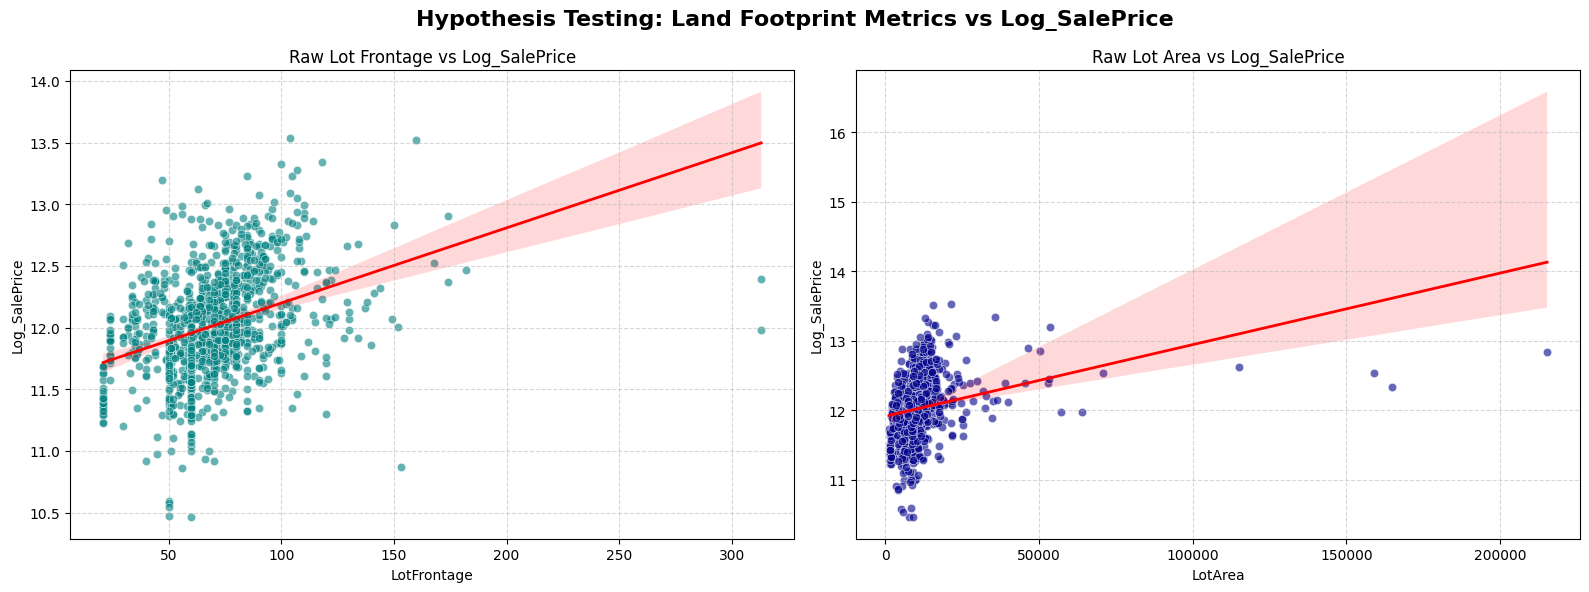

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hypothesis Testing: Land Footprint Metrics vs Log_SalePrice', fontsize=16, weight='bold', y=0.98)

sns.scatterplot(data=df, x='LotFrontage', y='Log_SalePrice', ax=axes[0], alpha=0.6, color='teal')
sns.regplot(data=df, x='LotFrontage', y='Log_SalePrice', ax=axes[0], scatter=False, color='red', line_kws={"linewidth": 2})
axes[0].set_title('Raw Lot Frontage vs Log_SalePrice', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(data=df, x='LotArea', y='Log_SalePrice', ax=axes[1], alpha=0.6, color='darkblue')
sns.regplot(data=df, x='LotArea', y='Log_SalePrice', ax=axes[1], scatter=False, color='red', line_kws={"linewidth": 2})
axes[1].set_title('Raw Lot Area vs Log_SalePrice', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

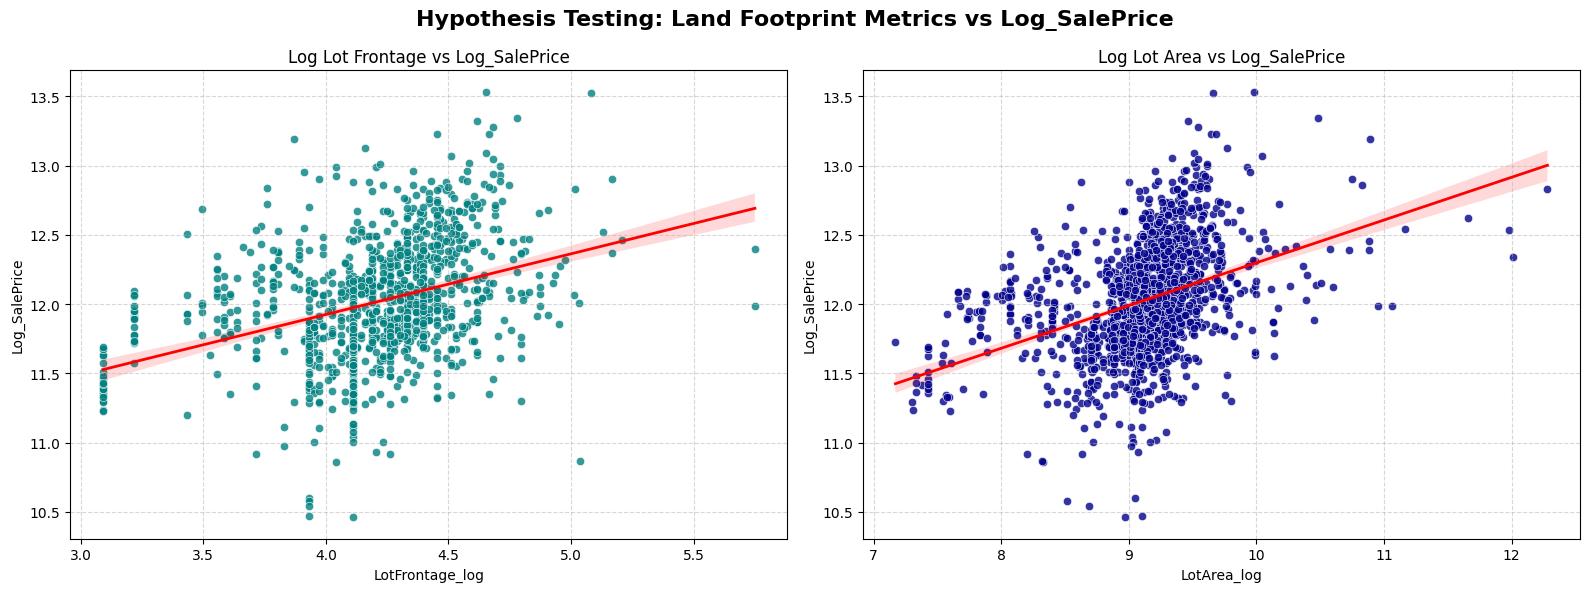

In [179]:
df["LotArea_log"] = np.log1p(df["LotArea"])
df["LotFrontage_log"] = np.log1p(df["LotFrontage"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hypothesis Testing: Land Footprint Metrics vs Log_SalePrice', fontsize=16, weight='bold', y=0.98)

sns.scatterplot(data=df, x='LotFrontage_log', y='Log_SalePrice', ax=axes[0], alpha=0.8, color='teal')
sns.regplot(data=df, x='LotFrontage_log', y='Log_SalePrice', ax=axes[0], scatter=False, color='red', line_kws={"linewidth": 2})
axes[0].set_title('Log Lot Frontage vs Log_SalePrice', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. LotArea Scatter Plot
sns.scatterplot(data=df, x='LotArea_log', y='Log_SalePrice', ax=axes[1], alpha=0.8, color='darkblue')
sns.regplot(data=df, x='LotArea_log', y='Log_SalePrice', ax=axes[1], scatter=False, color='red', line_kws={"linewidth": 2})
axes[1].set_title('Log Lot Area vs Log_SalePrice', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

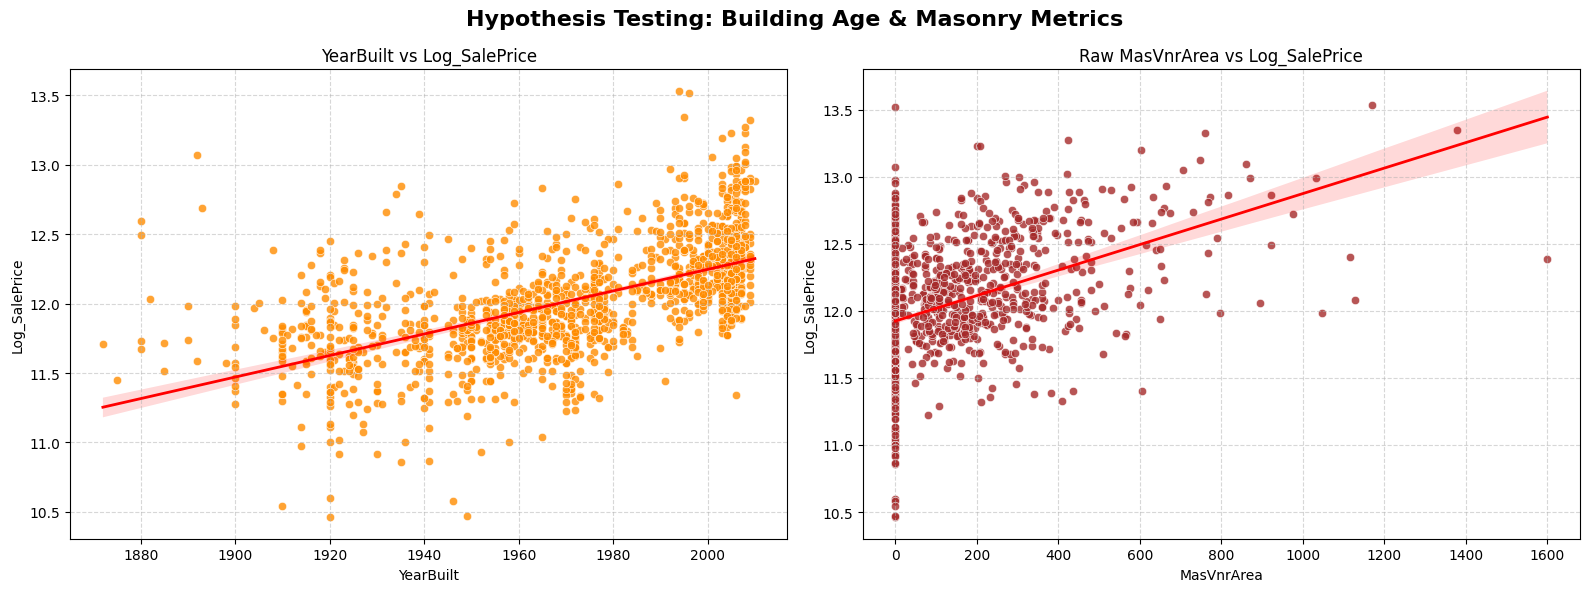

In [180]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hypothesis Testing: Building Age & Masonry Metrics', fontsize=16, weight='bold', y=0.98)

sns.scatterplot(data=df, x='YearBuilt', y='Log_SalePrice', ax=axes[0], alpha=0.8, color='darkorange')
sns.regplot(data=df, x='YearBuilt', y='Log_SalePrice', ax=axes[0], scatter=False, color='red', line_kws={"linewidth": 2})
axes[0].set_title('YearBuilt vs Log_SalePrice', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(data=df, x='MasVnrArea', y='Log_SalePrice', ax=axes[1], alpha=0.8, color='brown')
sns.regplot(data=df, x='MasVnrArea', y='Log_SalePrice', ax=axes[1], scatter=False, color='red', line_kws={"linewidth": 2})
axes[1].set_title('Raw MasVnrArea vs Log_SalePrice', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [181]:
df['Has_MasVnr'] = (df['MasVnrArea'] > 0).astype(int)
masonry_subset = df[df['Has_MasVnr'] == 1]

df['MasVnrArea_log'] = np.log1p(df['MasVnrArea'])
df['Age'] = df['YrSold'] - df['YearBuilt']

print("📊 HURDLE SPLIT PERFORMANCE REPORT")
print("-" * 50)
print(f"Raw YearBuilt Correlation:            {df['YearBuilt'].corr(df['Log_SalePrice']):.4f}")
print(f"Engineered Age Correlation:          {df['Age'].corr(df['Log_SalePrice']):.4f}")
print("-" * 50)
print(f"Raw MasVnrArea Correlation (Whole DF): {df['MasVnrArea'].corr(df['Log_SalePrice']):.4f}")
print(f"Log MasVnrArea Correlation (Whole DF): {df['MasVnrArea_log'].corr(df['Log_SalePrice']):.4f}")
print("-" * 50)
print(f"⭐ Has_MasVnr Binary Flag Correlation: {df['Has_MasVnr'].corr(df['Log_SalePrice']):.4f}")
print(f"⭐ Log MasVnrArea (Only Where Present): {np.log1p(masonry_subset['MasVnrArea']).corr(masonry_subset['Log_SalePrice']):.4f}")
print("-" * 50)

📊 HURDLE SPLIT PERFORMANCE REPORT
--------------------------------------------------
Raw YearBuilt Correlation:            0.5866
Engineered Age Correlation:          -0.5873
--------------------------------------------------
Raw MasVnrArea Correlation (Whole DF): 0.4308
Log MasVnrArea Correlation (Whole DF): 0.4187
--------------------------------------------------
⭐ Has_MasVnr Binary Flag Correlation: 0.3823
⭐ Log MasVnrArea (Only Where Present): 0.3206
--------------------------------------------------


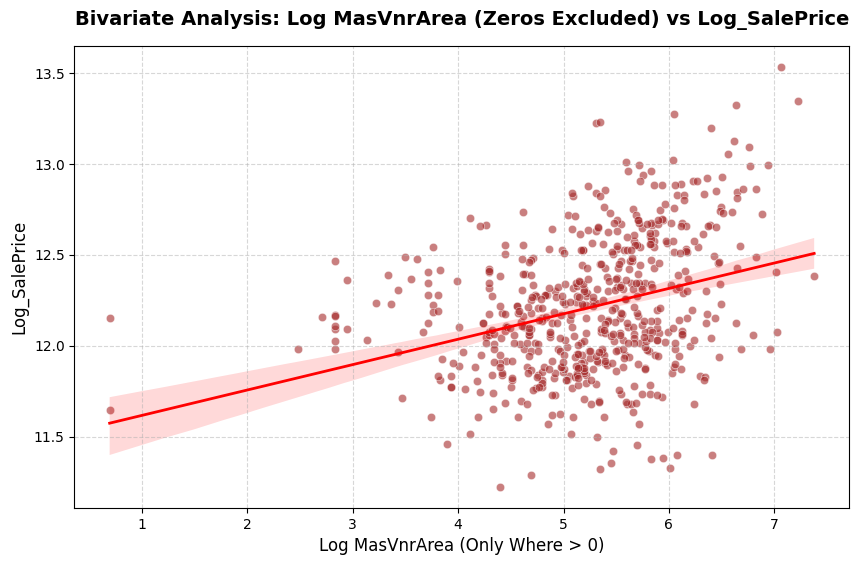

⭐ Cleaned Log MasVnrArea Correlation (Ignoring Zeros): 0.3206


In [182]:
df['MasVnrArea_log_no_zeros'] = np.log1p(df['MasVnrArea']).replace(0, np.nan)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='MasVnrArea_log_no_zeros', y='Log_SalePrice', alpha=0.6, color='brown')
sns.regplot(data=df, x='MasVnrArea_log_no_zeros', y='Log_SalePrice', scatter=False, color='red', line_kws={"linewidth": 2})

plt.title('Bivariate Analysis: Log MasVnrArea (Zeros Excluded) vs Log_SalePrice', fontsize=14, weight='bold', pad=15)
plt.xlabel('Log MasVnrArea (Only Where > 0)', fontsize=12)
plt.ylabel('Log_SalePrice', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

clean_corr = df['MasVnrArea_log_no_zeros'].corr(df['Log_SalePrice'])
print(f"⭐ Cleaned Log MasVnrArea Correlation (Ignoring Zeros): {clean_corr:.4f}")

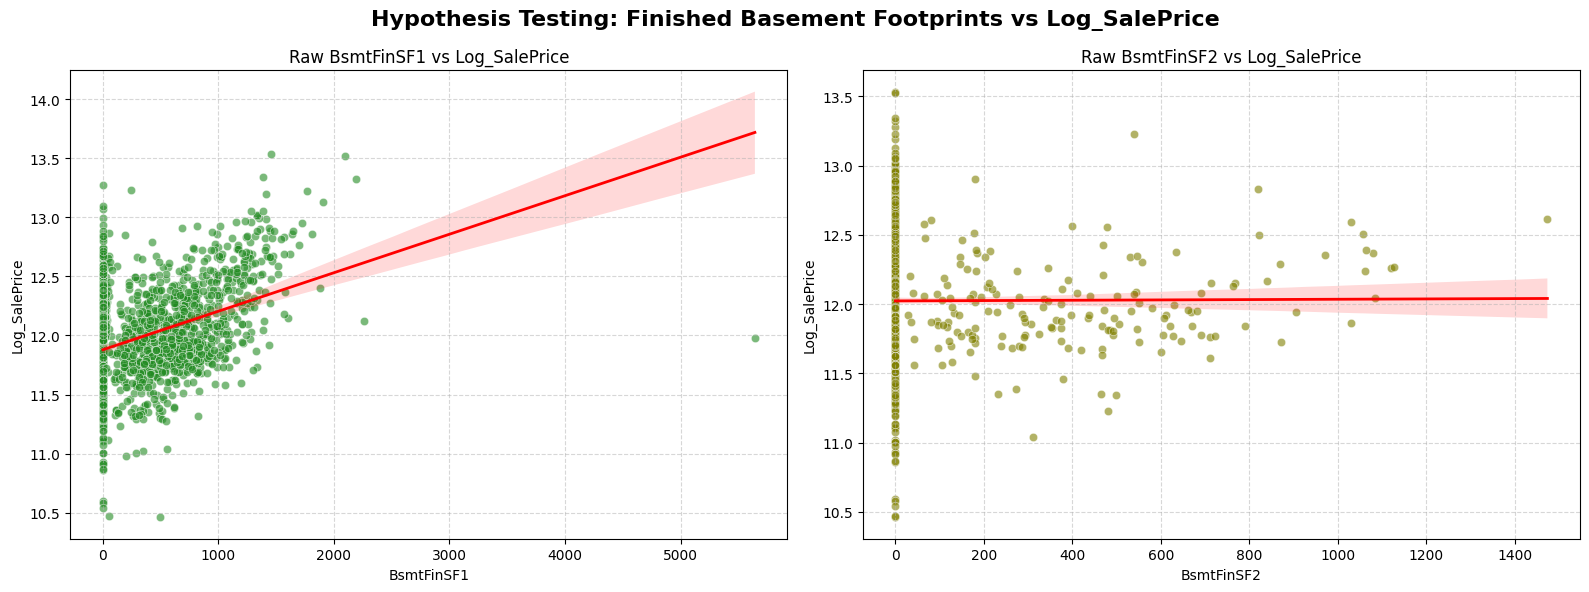

📊 BASELINE BASEMENT CORRELATION REPORT
--------------------------------------------------
Raw BsmtFinSF1 Correlation: 0.3720
Raw BsmtFinSF2 Correlation: 0.0048
--------------------------------------------------


In [183]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hypothesis Testing: Finished Basement Footprints vs Log_SalePrice', fontsize=16, weight='bold', y=0.98)


sns.scatterplot(data=df, x='BsmtFinSF1', y='Log_SalePrice', ax=axes[0], alpha=0.6, color='forestgreen')
sns.regplot(data=df, x='BsmtFinSF1', y='Log_SalePrice', ax=axes[0], scatter=False, color='red', line_kws={"linewidth": 2})
axes[0].set_title('Raw BsmtFinSF1 vs Log_SalePrice', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)


sns.scatterplot(data=df, x='BsmtFinSF2', y='Log_SalePrice', ax=axes[1], alpha=0.6, color='olive')
sns.regplot(data=df, x='BsmtFinSF2', y='Log_SalePrice', ax=axes[1], scatter=False, color='red', line_kws={"linewidth": 2})
axes[1].set_title('Raw BsmtFinSF2 vs Log_SalePrice', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("📊 BASELINE BASEMENT CORRELATION REPORT")
print("-" * 50)
print(f"Raw BsmtFinSF1 Correlation: {df['BsmtFinSF1'].corr(df['Log_SalePrice']):.4f}")
print(f"Raw BsmtFinSF2 Correlation: {df['BsmtFinSF2'].corr(df['Log_SalePrice']):.4f}")
print("-" * 50)

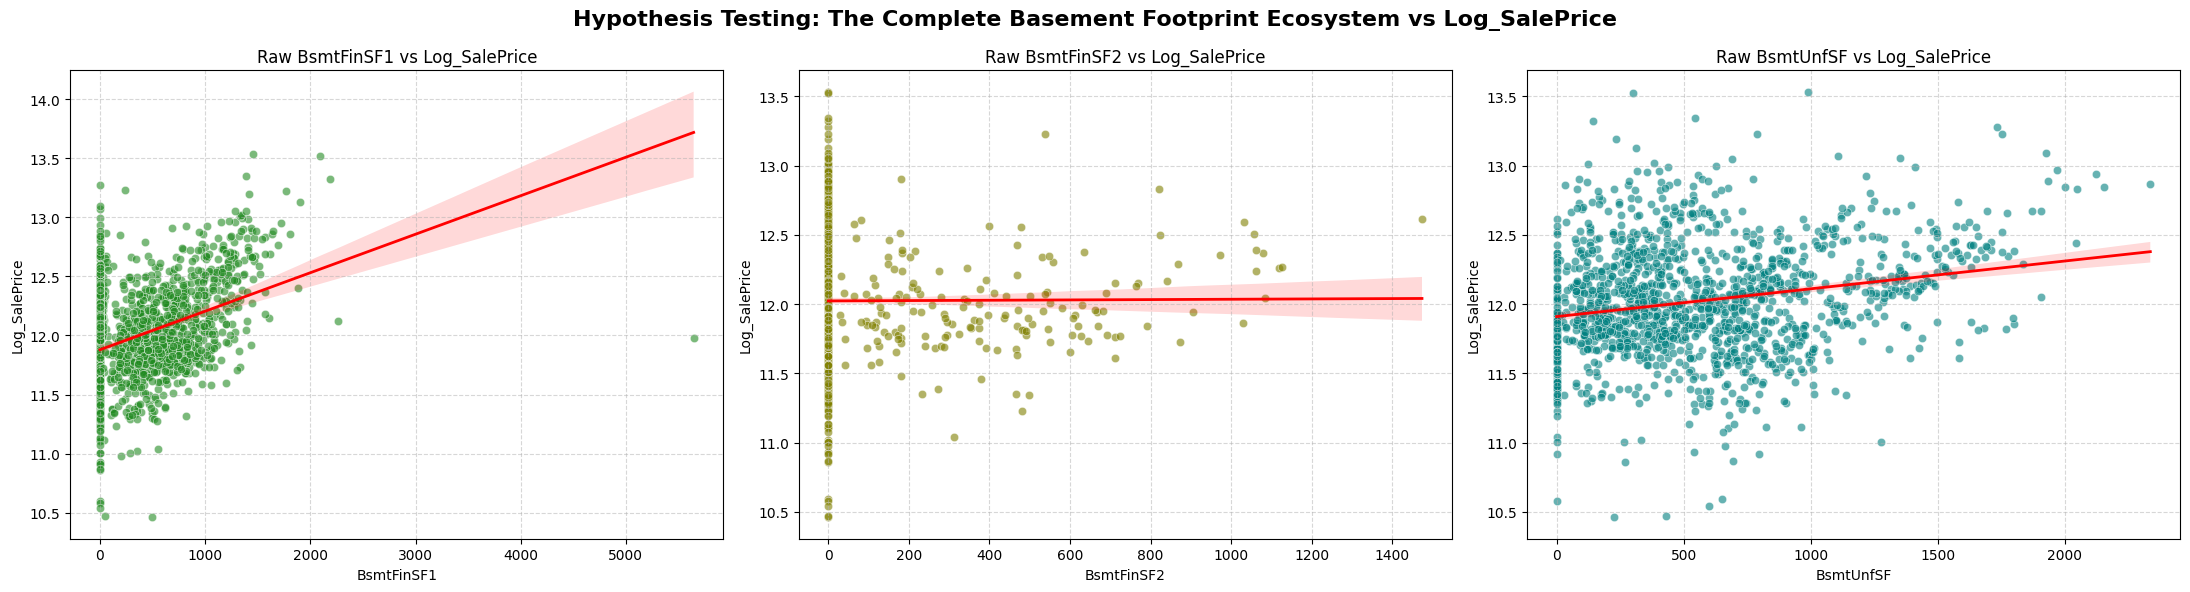

📊 THE COMPONENT BASEMENT CORRELATION LEDGER
--------------------------------------------------
Raw BsmtFinSF1 (Primary Finished) Corr:   0.3720
Raw BsmtFinSF2 (Secondary Finished) Corr: 0.0048
Raw BsmtUnfSF  (Unfinished Space) Corr:   0.2220
--------------------------------------------------


In [184]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Hypothesis Testing: The Complete Basement Footprint Ecosystem vs Log_SalePrice', fontsize=16, weight='bold', y=0.98)

sns.scatterplot(data=df, x='BsmtFinSF1', y='Log_SalePrice', ax=axes[0], alpha=0.6, color='forestgreen')
sns.regplot(data=df, x='BsmtFinSF1', y='Log_SalePrice', ax=axes[0], scatter=False, color='red', line_kws={"linewidth": 2})
axes[0].set_title('Raw BsmtFinSF1 vs Log_SalePrice', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(data=df, x='BsmtFinSF2', y='Log_SalePrice', ax=axes[1], alpha=0.6, color='olive')
sns.regplot(data=df, x='BsmtFinSF2', y='Log_SalePrice', ax=axes[1], scatter=False, color='red', line_kws={"linewidth": 2})
axes[1].set_title('Raw BsmtFinSF2 vs Log_SalePrice', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

sns.scatterplot(data=df, x='BsmtUnfSF', y='Log_SalePrice', ax=axes[2], alpha=0.6, color='teal')
sns.regplot(data=df, x='BsmtUnfSF', y='Log_SalePrice', ax=axes[2], scatter=False, color='red', line_kws={"linewidth": 2})
axes[2].set_title('Raw BsmtUnfSF vs Log_SalePrice', fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("📊 THE COMPONENT BASEMENT CORRELATION LEDGER")
print("-" * 50)
print(f"Raw BsmtFinSF1 (Primary Finished) Corr:   {df['BsmtFinSF1'].corr(df['Log_SalePrice']):.4f}")
print(f"Raw BsmtFinSF2 (Secondary Finished) Corr: {df['BsmtFinSF2'].corr(df['Log_SalePrice']):.4f}")
print(f"Raw BsmtUnfSF  (Unfinished Space) Corr:   {df['BsmtUnfSF'].corr(df['Log_SalePrice']):.4f}")
print("-" * 50)

In [185]:
# 1. Clean the extreme horizontal outlier we found (>5000 sq ft)
df = df[df['BsmtFinSF1'] < 5000]

# 2. Build the structural hurdle flag
df['Has_Basement'] = (df['TotalBsmtSF'] > 0).astype(int)

# 3. Keep the two master signals raw (Zeros kept intact for the model)
# TotalBsmtSF tracks overall foundation scale; BsmtFinSF1 tracks active luxury finish
df['TotalBsmtSF'] = df['TotalBsmtSF'].fillna(0)
df['BsmtFinSF1'] = df['BsmtFinSF1'].fillna(0)

# 4. Check the clean master correlations
print("🏁 FINAL MODEL-READY BASEMENT METRICS")
print("-" * 50)
print(f"Has_Basement Hurdle Flag Corr:   {df['Has_Basement'].corr(df['Log_SalePrice']):.4f}")
print(f"Total Foundation Size Corr:      {df['TotalBsmtSF'].corr(df['Log_SalePrice']):.4f}")
print(f"Primary Finished Space Corr:     {df['BsmtFinSF1'].corr(df['Log_SalePrice']):.4f}")
print(f"BsmtUnfSF (Unfinished Space) Corr:   {df['BsmtUnfSF'].corr(df['Log_SalePrice']):.4f}")
print("-" * 50)

# 5. Safely drop the redundant slices to prevent multi-collinearity
df = df.drop(columns=['BsmtFinSF2', 'BsmtFinSF1_clean'], errors='ignore')

🏁 FINAL MODEL-READY BASEMENT METRICS
--------------------------------------------------
Has_Basement Hurdle Flag Corr:   0.1996
Total Foundation Size Corr:      0.6429
Primary Finished Space Corr:     0.3907
BsmtUnfSF (Unfinished Space) Corr:   0.2220
--------------------------------------------------


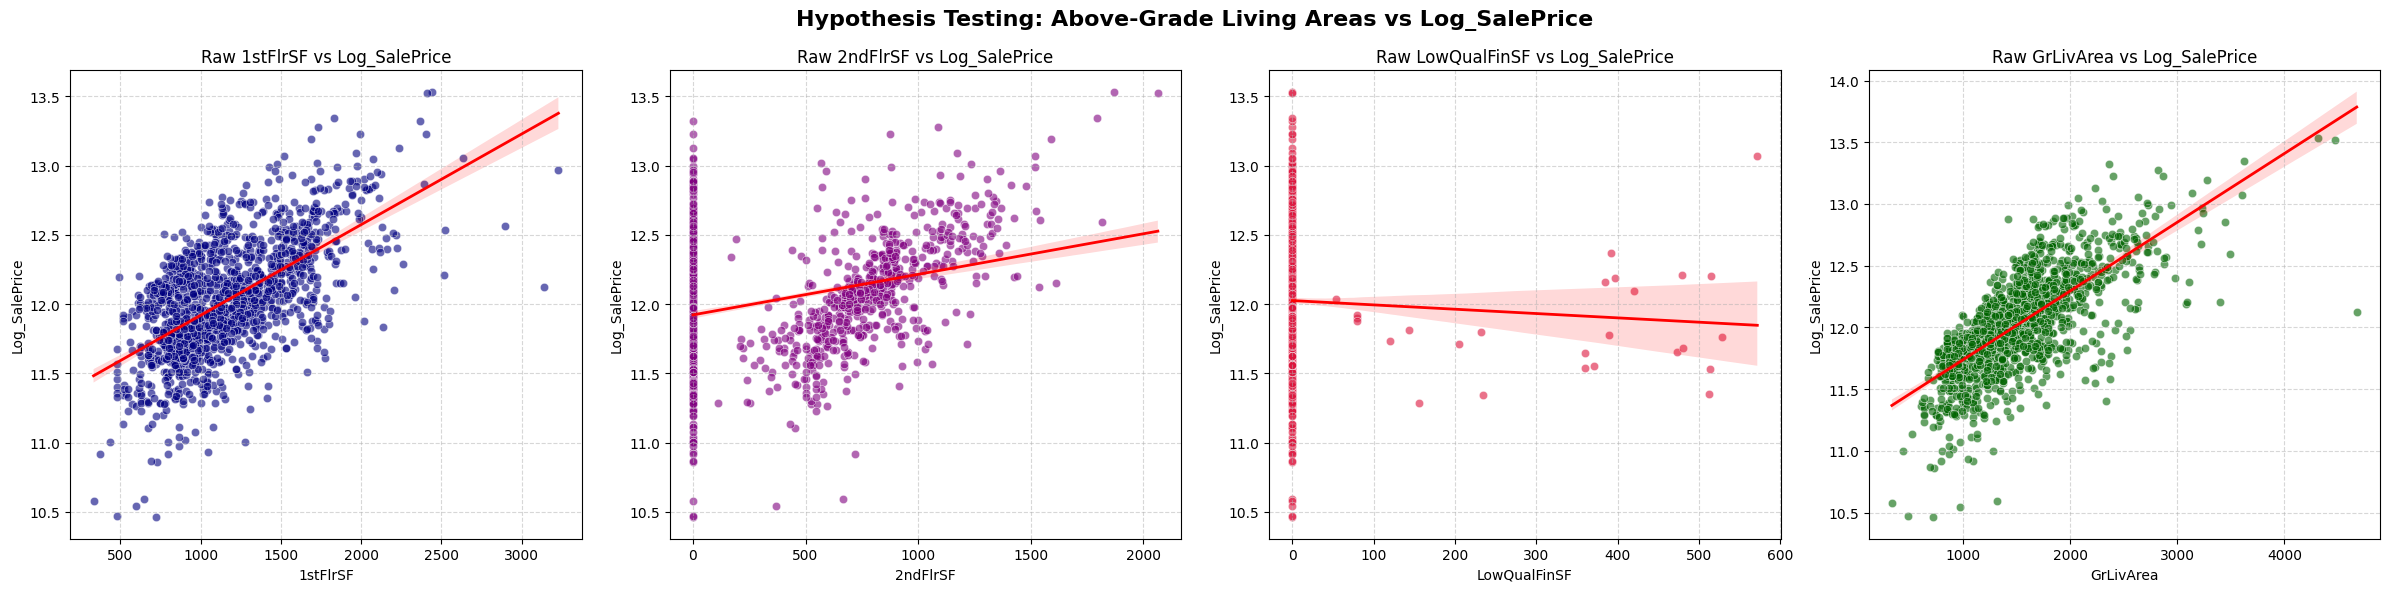

📊 LIVING AREA CORRELATION LEDGER
--------------------------------------------------
Raw 1stFlrSF Correlation:      0.6155
Raw 2ndFlrSF Correlation:      0.3196
Raw LowQualFinSF Correlation:  -0.0380
Raw GrLivArea Correlation:     0.7168
--------------------------------------------------


In [186]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a clean 1x4 grid to analyze the living area ecosystem
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Hypothesis Testing: Above-Grade Living Areas vs Log_SalePrice', fontsize=16, weight='bold', y=0.98)

# 1. 1stFlrSF (First Floor Square Footage)
sns.scatterplot(data=df, x='1stFlrSF', y='Log_SalePrice', ax=axes[0], alpha=0.6, color='navy')
sns.regplot(data=df, x='1stFlrSF', y='Log_SalePrice', ax=axes[0], scatter=False, color='red', line_kws={"linewidth": 2})
axes[0].set_title('Raw 1stFlrSF vs Log_SalePrice', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. 2ndFlrSF (Second Floor Square Footage)
sns.scatterplot(data=df, x='2ndFlrSF', y='Log_SalePrice', ax=axes[1], alpha=0.6, color='purple')
sns.regplot(data=df, x='2ndFlrSF', y='Log_SalePrice', ax=axes[1], scatter=False, color='red', line_kws={"linewidth": 2})
axes[1].set_title('Raw 2ndFlrSF vs Log_SalePrice', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. LowQualFinSF (Low Quality Finished Square Footage)
sns.scatterplot(data=df, x='LowQualFinSF', y='Log_SalePrice', ax=axes[2], alpha=0.6, color='crimson')
sns.regplot(data=df, x='LowQualFinSF', y='Log_SalePrice', ax=axes[2], scatter=False, color='red', line_kws={"linewidth": 2})
axes[2].set_title('Raw LowQualFinSF vs Log_SalePrice', fontsize=12)
axes[2].grid(True, linestyle='--', alpha=0.5)

# 4. GrLivArea (Total Above Grade Living Area)
sns.scatterplot(data=df, x='GrLivArea', y='Log_SalePrice', ax=axes[3], alpha=0.6, color='darkgreen')
sns.regplot(data=df, x='GrLivArea', y='Log_SalePrice', ax=axes[3], scatter=False, color='red', line_kws={"linewidth": 2})
axes[3].set_title('Raw GrLivArea vs Log_SalePrice', fontsize=12)
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("📊 LIVING AREA CORRELATION LEDGER")
print("-" * 50)
print(f"Raw 1stFlrSF Correlation:      {df['1stFlrSF'].corr(df['Log_SalePrice']):.4f}")
print(f"Raw 2ndFlrSF Correlation:      {df['2ndFlrSF'].corr(df['Log_SalePrice']):.4f}")
print(f"Raw LowQualFinSF Correlation:  {df['LowQualFinSF'].corr(df['Log_SalePrice']):.4f}")
print(f"Raw GrLivArea Correlation:     {df['GrLivArea'].corr(df['Log_SalePrice']):.4f}")
print("-" * 50)

In [187]:
# 1. eliminate the two massive GrLivArea outliers (>4000 sq ft)
df = df[df['GrLivArea'] < 4000]
df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)
df = df.drop(columns=['2ndFlrSF', 'LowQualFinSF'], errors='ignore')

print("🏁 MODEL-READY LIVING AREA FEATURES")
print("-" * 50)
print(f"Total Above-Grade Living Area (GrLivArea) Corr: {df['GrLivArea'].corr(df['Log_SalePrice']):.4f}")
print(f"First Floor Footprint (1stFlrSF) Corr:         {df['1stFlrSF'].corr(df['Log_SalePrice']):.4f}")
print(f"Has2ndFloor Binary Switch Corr:                {df['Has2ndFloor'].corr(df['Log_SalePrice']):.4f}")
print("-" * 50)

🏁 MODEL-READY LIVING AREA FEATURES
--------------------------------------------------
Total Above-Grade Living Area (GrLivArea) Corr: 0.7188
First Floor Footprint (1stFlrSF) Corr:         0.6137
Has2ndFloor Binary Switch Corr:                0.1462
--------------------------------------------------


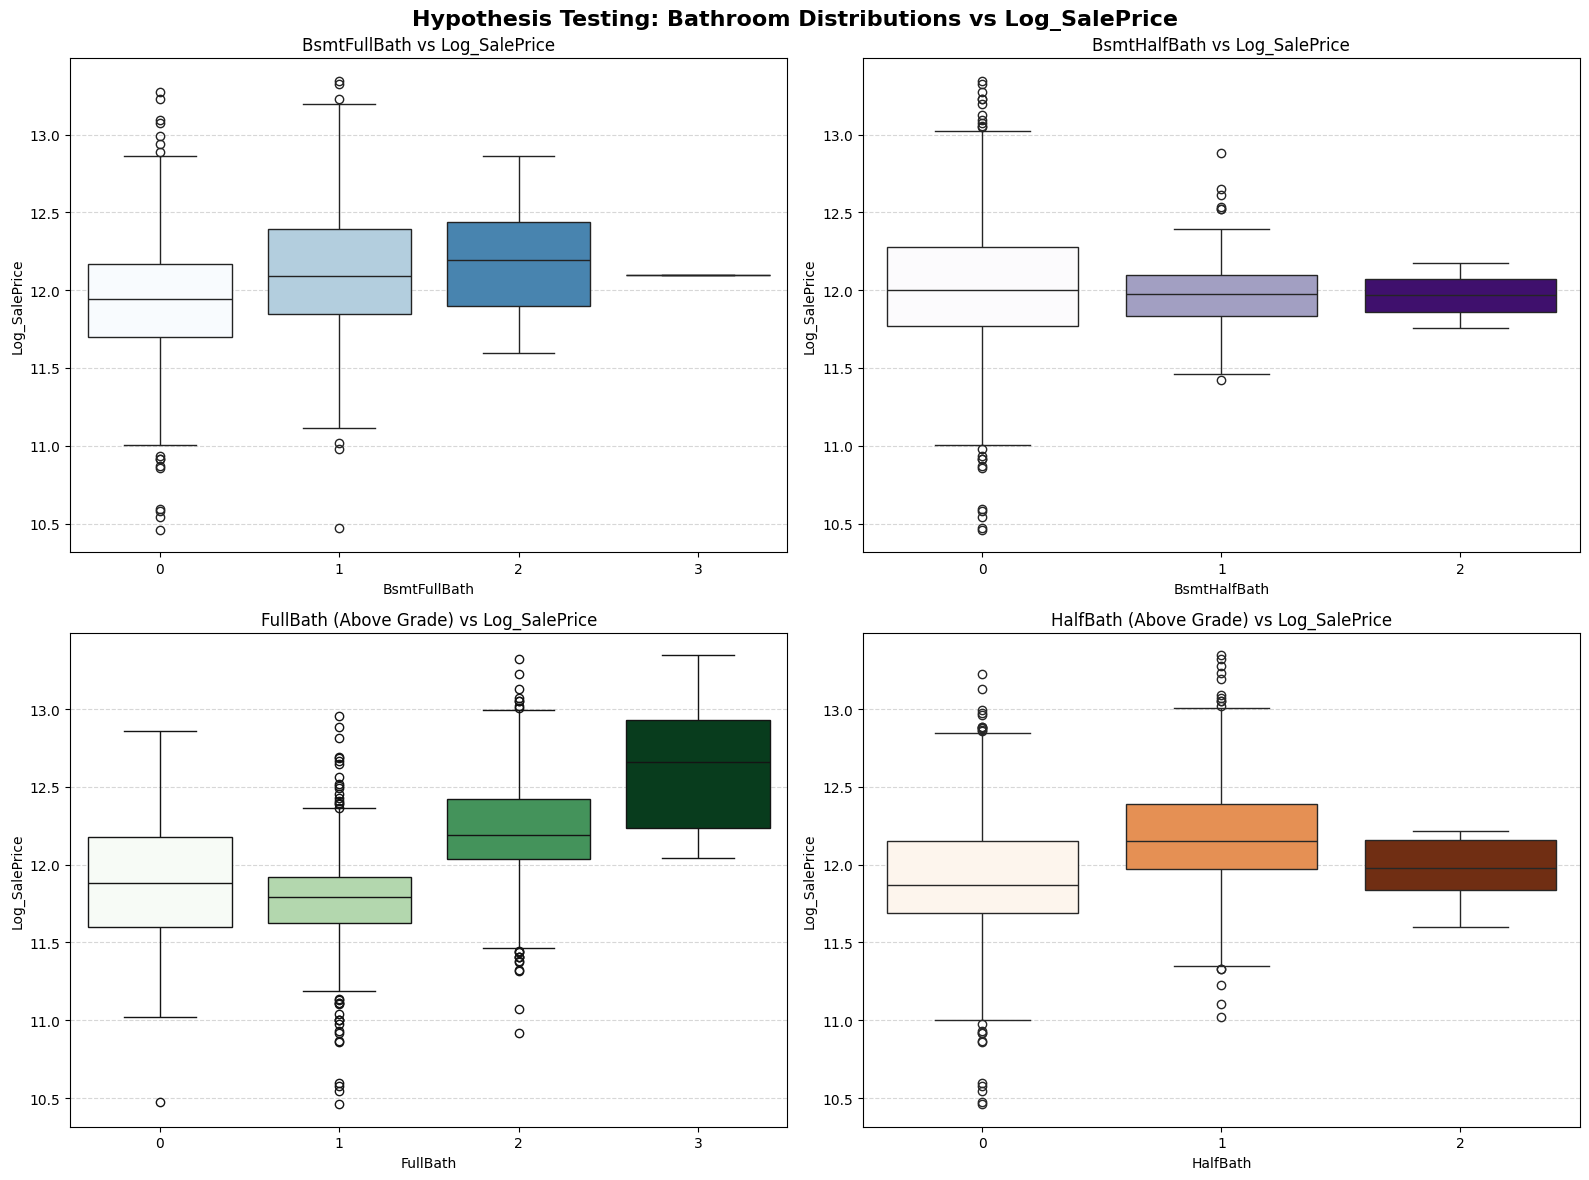

📊 BATHROOM BASELINE CORRELATION LEDGER
--------------------------------------------------
BsmtFullBath Correlation: 0.2389
BsmtHalfBath Correlation: -0.0150
FullBath Correlation:     0.5909
HalfBath Correlation:     0.3112
--------------------------------------------------


In [188]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Hypothesis Testing: Bathroom Distributions vs Log_SalePrice', fontsize=16, weight='bold', y=0.98)

sns.boxplot(data=df, x='BsmtFullBath', y='Log_SalePrice', ax=axes[0,0], hue='BsmtFullBath', palette='Blues', legend=False)
axes[0,0].set_title('BsmtFullBath vs Log_SalePrice', fontsize=12)
axes[0,0].grid(axis='y', linestyle='--', alpha=0.5)

sns.boxplot(data=df, x='BsmtHalfBath', y='Log_SalePrice', ax=axes[0,1], hue='BsmtHalfBath', palette='Purples', legend=False)
axes[0,1].set_title('BsmtHalfBath vs Log_SalePrice', fontsize=12)
axes[0,1].grid(axis='y', linestyle='--', alpha=0.5)

sns.boxplot(data=df, x='FullBath', y='Log_SalePrice', ax=axes[1,0], hue='FullBath', palette='Greens', legend=False)
axes[1,0].set_title('FullBath (Above Grade) vs Log_SalePrice', fontsize=12)
axes[1,0].grid(axis='y', linestyle='--', alpha=0.5)

sns.boxplot(data=df, x='HalfBath', y='Log_SalePrice', ax=axes[1,1], hue='HalfBath', palette='Oranges', legend=False)
axes[1,1].set_title('HalfBath (Above Grade) vs Log_SalePrice', fontsize=12)
axes[1,1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("📊 BATHROOM BASELINE CORRELATION LEDGER")
print("-" * 50)
print(f"BsmtFullBath Correlation: {df['BsmtFullBath'].corr(df['Log_SalePrice']):.4f}")
print(f"BsmtHalfBath Correlation: {df['BsmtHalfBath'].corr(df['Log_SalePrice']):.4f}")
print(f"FullBath Correlation:     {df['FullBath'].corr(df['Log_SalePrice']):.4f}")
print(f"HalfBath Correlation:     {df['HalfBath'].corr(df['Log_SalePrice']):.4f}")
print("-" * 50)

In [189]:
# 1. Combine all bathroom components into a single fractional master feature
df['TotalBathrooms'] = (
    df['FullBath'] + 
    (df['HalfBath'] * 0.5) + 
    df['BsmtFullBath'] + 
    (df['BsmtHalfBath'] * 0.5)
)

# 2. Benchmark our engineered master feature against the raw components
print("🏁 MASTER BATHROOM OPTIMIZATION REPORT")
print("-" * 55)
print(f"Raw FullBath Baseline Corr:     {df['FullBath'].corr(df['Log_SalePrice']):.4f}")
print(f"⭐ Engineered TotalBathrooms Corr: {df['TotalBathrooms'].corr(df['Log_SalePrice']):.4f}")
print("-" * 55)

# 3. Safely drop the raw individual slices to clean up dimensions
df = df.drop(columns=['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath'], errors='ignore')

🏁 MASTER BATHROOM OPTIMIZATION REPORT
-------------------------------------------------------
Raw FullBath Baseline Corr:     0.5909
⭐ Engineered TotalBathrooms Corr: 0.6729
-------------------------------------------------------


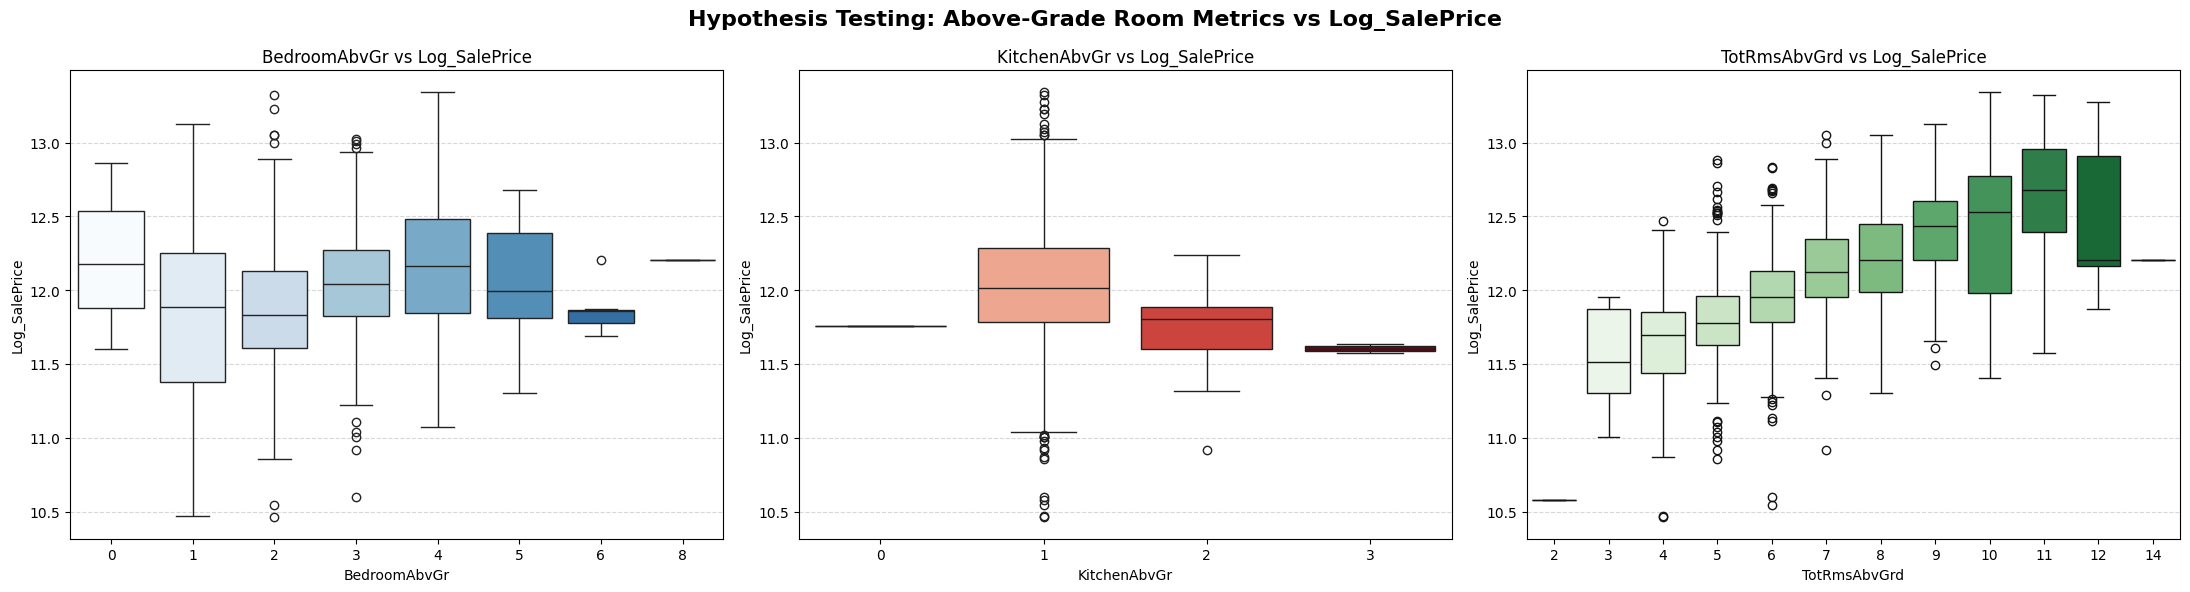

📊 ABOVE-GRADE ROOMS BASELINE CORRELATION LEDGER
-------------------------------------------------------
BedroomAbvGr Correlation: 0.2041
KitchenAbvGr Correlation: -0.1479
TotRmsAbvGrd Correlation: 0.5334
-------------------------------------------------------


In [190]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Hypothesis Testing: Above-Grade Room Metrics vs Log_SalePrice', fontsize=16, weight='bold', y=0.98)

sns.boxplot(data=df, x='BedroomAbvGr', y='Log_SalePrice', ax=axes[0], hue='BedroomAbvGr', palette='Blues', legend=False)
axes[0].set_title('BedroomAbvGr vs Log_SalePrice', fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.boxplot(data=df, x='KitchenAbvGr', y='Log_SalePrice', ax=axes[1], hue='KitchenAbvGr', palette='Reds', legend=False)
axes[1].set_title('KitchenAbvGr vs Log_SalePrice', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

sns.boxplot(data=df, x='TotRmsAbvGrd', y='Log_SalePrice', ax=axes[2], hue='TotRmsAbvGrd', palette='Greens', legend=False)
axes[2].set_title('TotRmsAbvGrd vs Log_SalePrice', fontsize=12)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("📊 ABOVE-GRADE ROOMS BASELINE CORRELATION LEDGER")
print("-" * 55)
print(f"BedroomAbvGr Correlation: {df['BedroomAbvGr'].corr(df['Log_SalePrice']):.4f}")
print(f"KitchenAbvGr Correlation: {df['KitchenAbvGr'].corr(df['Log_SalePrice']):.4f}")
print(f"TotRmsAbvGrd Correlation: {df['TotRmsAbvGrd'].corr(df['Log_SalePrice']):.4f}")
print("-" * 55)

In [191]:
# 1. Capture your hunch: Calculate the average square footage per above-grade room
df['AvgRoomSize'] = df['GrLivArea'] / df['TotRmsAbvGrd']

# 2. Benchmark the efficiency of your new engineered feature
print("📈 ROOM DENSITY EFFICIENCY REPORT")
print("-" * 55)
print(f"Raw TotRmsAbvGrd Baseline Corr: {df['TotRmsAbvGrd'].corr(df['Log_SalePrice']):.4f}")
print(f"⭐ Engineered AvgRoomSize Corr:    {df['AvgRoomSize'].corr(df['Log_SalePrice']):.4f}")
print("-" * 55)

# 3. Clean up the dimensions
# Now you can safely drop TotRmsAbvGrd and KitchenAbvGr!
df = df.drop(columns=['TotRmsAbvGrd', 'KitchenAbvGr'], errors='ignore')

📈 ROOM DENSITY EFFICIENCY REPORT
-------------------------------------------------------
Raw TotRmsAbvGrd Baseline Corr: 0.5334
⭐ Engineered AvgRoomSize Corr:    0.5590
-------------------------------------------------------
